In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torch.nn as nn



SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


In [116]:
DATASET_PATH = "Dataset/jena_climate/jena_climate_2009_2016.csv"

df = pd.read_csv(DATASET_PATH)

print("Forma del dataset:", df.shape)

df.head()

Forma del dataset: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [117]:
print("Columnas del dataset:\n")

for column in df.columns:
    print(column)

Columnas del dataset:

Date Time
p (mbar)
T (degC)
Tpot (K)
Tdew (degC)
rh (%)
VPmax (mbar)
VPact (mbar)
VPdef (mbar)
sh (g/kg)
H2OC (mmol/mol)
rho (g/m**3)
wv (m/s)
max. wv (m/s)
wd (deg)


In [118]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), str(1)
memory usage: 48.1 MB
None


In [119]:
print(df.shape)

(420551, 15)


In [120]:
print(df.describe())

            p (mbar)       T (degC)       Tpot (K)    Tdew (degC)  \
count  420551.000000  420551.000000  420551.000000  420551.000000   
mean      989.212776       9.450147     283.492743       4.955854   
std         8.358481       8.423365       8.504471       6.730674   
min       913.600000     -23.010000     250.600000     -25.010000   
25%       984.200000       3.360000     277.430000       0.240000   
50%       989.580000       9.420000     283.470000       5.220000   
75%       994.720000      15.470000     289.530000      10.070000   
max      1015.350000      37.280000     311.340000      23.110000   

              rh (%)   VPmax (mbar)   VPact (mbar)   VPdef (mbar)  \
count  420551.000000  420551.000000  420551.000000  420551.000000   
mean       76.008259      13.576251       9.533756       4.042412   
std        16.476175       7.739020       4.184164       4.896851   
min        12.950000       0.950000       0.790000       0.000000   
25%        65.210000       7.7800

In [121]:
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

In [122]:
print(df["Date Time"].head())

print("\nIntervalos entre mediciones:")
print(df["Date Time"].diff().value_counts().head())

0   2009-01-01 00:10:00
1   2009-01-01 00:20:00
2   2009-01-01 00:30:00
3   2009-01-01 00:40:00
4   2009-01-01 00:50:00
Name: Date Time, dtype: datetime64[us]

Intervalos entre mediciones:
Date Time
0 days 00:10:00      420543
0 days 00:20:00           2
0 days 00:30:00           1
-1 days +00:10:00         1
-2 days +17:40:00         1
Name: count, dtype: int64


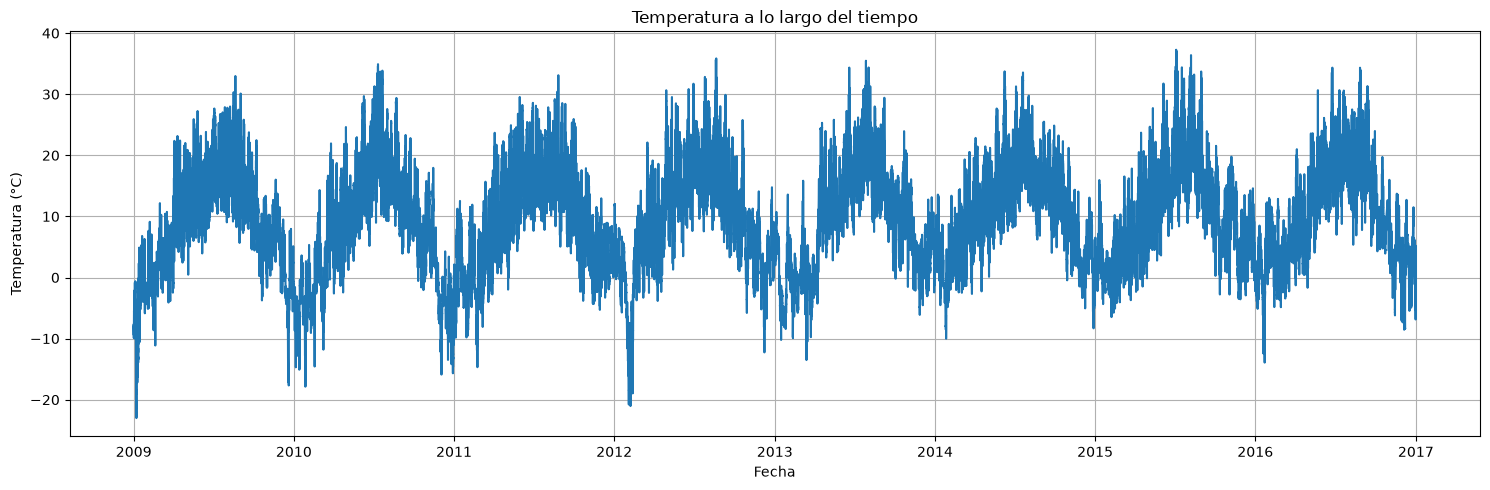

In [123]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["Date Time"],
    df["T (degC)"]
)

plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.title("Temperatura a lo largo del tiempo")

plt.grid(True)
plt.tight_layout()
plt.show()

In [124]:
df = df.sort_values("Date Time").reset_index(drop=True)

In [125]:
intervalos = df["Date Time"].diff()

print(intervalos.value_counts().head())

Date Time
0 days 00:10:00    420218
0 days 00:00:00       327
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
Name: count, dtype: int64


In [126]:
print("Primer registro:")
print(df["Date Time"].iloc[0])

print("\nÚltimo registro:")
print(df["Date Time"].iloc[-1])

print("\nCantidad de registros:")
print(len(df))

Primer registro:
2009-01-01 00:10:00

Último registro:
2017-01-01 00:00:00

Cantidad de registros:
420551


In [127]:
print("\nIntervalo mínimo:")
print(intervalos.min())

print("\nIntervalo máximo:")
print(intervalos.max())


Intervalo mínimo:
0 days 00:00:00

Intervalo máximo:
3 days 02:20:00


In [128]:
print("Fecha mínima:", df["Date Time"].min())
print("Fecha máxima:", df["Date Time"].max())

Fecha mínima: 2009-01-01 00:10:00
Fecha máxima: 2017-01-01 00:00:00


In [129]:
print(df["Date Time"].dt.year.value_counts().sort_index())

Date Time
2009    52557
2010    52704
2011    52560
2012    52704
2013    52559
2014    52647
2015    52560
2016    52259
2017        1
Name: count, dtype: int64


In [130]:
# Eliminar el único registro de 2017
df = df[df["Date Time"].dt.year <= 2016].copy()

# División temporal
train_df = df[df["Date Time"].dt.year <= 2014].copy()
val_df = df[df["Date Time"].dt.year == 2015].copy()
test_df = df[df["Date Time"].dt.year == 2016].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (315731, 15)
Validation: (52560, 15)
Test: (52259, 15)


In [131]:
# ==============================
# Variables cíclicas
# ==============================

for data in [train_df, val_df, test_df]:

    radians = np.deg2rad(data["wd (deg)"])

    data["wd_sin"] = np.sin(radians)
    data["wd_cos"] = np.cos(radians)

# Eliminar la dirección original
train_df = train_df.drop(columns=["wd (deg)"])
val_df = val_df.drop(columns=["wd (deg)"])
test_df = test_df.drop(columns=["wd (deg)"])

In [132]:
print("Train:")
print(train_df.head())

print("\nCantidad de columnas:", len(train_df.columns))

Train:
            Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0 2009-01-01 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1 2009-01-01 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2 2009-01-01 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3 2009-01-01 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4 2009-01-01 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd_sin    wd_cos  
0       1307.75      1

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [134]:
feature_columns = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd_sin",
    "wd_cos"
]

In [135]:
scaler.fit(train_df[feature_columns])

train_df[feature_columns] = scaler.transform(
    train_df[feature_columns]
)

val_df[feature_columns] = scaler.transform(
    val_df[feature_columns]
)

test_df[feature_columns] = scaler.transform(
    test_df[feature_columns]
)

In [136]:
print("Media de TRAIN:")
print(train_df[feature_columns].mean().round(3))

print("\nDesviación estándar de TRAIN:")
print(train_df[feature_columns].std().round(3))

Media de TRAIN:


p (mbar)           0.0
T (degC)          -0.0
Tpot (K)          -0.0
Tdew (degC)       -0.0
rh (%)             0.0
VPmax (mbar)       0.0
VPact (mbar)      -0.0
VPdef (mbar)      -0.0
sh (g/kg)         -0.0
H2OC (mmol/mol)   -0.0
rho (g/m**3)      -0.0
wv (m/s)          -0.0
max. wv (m/s)     -0.0
wd_sin            -0.0
wd_cos             0.0
dtype: float64

Desviación estándar de TRAIN:
p (mbar)           1.0
T (degC)           1.0
Tpot (K)           1.0
Tdew (degC)        1.0
rh (%)             1.0
VPmax (mbar)       1.0
VPact (mbar)       1.0
VPdef (mbar)       1.0
sh (g/kg)          1.0
H2OC (mmol/mol)    1.0
rho (g/m**3)       1.0
wv (m/s)           1.0
max. wv (m/s)      1.0
wd_sin             1.0
wd_cos             1.0
dtype: float64


In [137]:
X_train_data = train_df[feature_columns].values
X_val_data = val_df[feature_columns].values
X_test_data = test_df[feature_columns].values

In [138]:
print("Train:", X_train_data.shape)
print("Validation:", X_val_data.shape)
print("Test:", X_test_data.shape)

Train: (315731, 15)
Validation: (52560, 15)
Test: (52259, 15)


In [139]:
SEQUENCE_LENGTH = 144
FORECAST_HORIZON = 6

# Primera ventana
X_sample = X_train_data[:SEQUENCE_LENGTH]

# Temperatura de los siguientes 6 pasos
temperature_index = feature_columns.index("T (degC)")

Y_sample = X_train_data[
    SEQUENCE_LENGTH:SEQUENCE_LENGTH + FORECAST_HORIZON,
    temperature_index
]

print("Forma de X:", X_sample.shape)
print("Forma de Y:", Y_sample.shape)

print("\nX:")
print(X_sample[:3])

print("\nY:")
print(Y_sample)

Forma de X: (144, 15)
Forma de Y: (6,)

X:
[[ 0.95241716 -2.01525746 -2.07525253 -1.97688129  1.02618304 -1.32457913
  -1.51144485 -0.77940467 -1.51442689 -1.51670089  2.25152344 -0.726246
  -0.77218709  1.01881461 -0.8435052 ]
 [ 0.95852363 -2.06094051 -2.12055348 -2.03178458  1.03226008 -1.33777339
  -1.53286678 -0.78151749 -1.53317714 -1.53786431  2.30219854 -0.92847597
  -0.88005039  1.38939653 -0.61361381]
 [ 0.95363845 -2.07265411 -2.1321691  -2.03611905  1.06264529 -1.34041225
  -1.535247   -0.78363031 -1.53692719 -1.5402158   2.31307514 -1.27422398
  -1.25541469  0.50198559 -0.98837571]]

Y:
[-1.61465228 -1.62285181 -1.62168044 -1.60879548 -1.59473916 -1.59591052]


In [140]:
X_sample_2 = X_train_data[1:1 + SEQUENCE_LENGTH]

Y_sample_2 = X_train_data[
    1 + SEQUENCE_LENGTH:
    1 + SEQUENCE_LENGTH + FORECAST_HORIZON,
    temperature_index
]

print("X_sample_2:", X_sample_2.shape)
print("Y_sample_2:", Y_sample_2.shape)

print("\nPrimera temperatura de X_sample:")
print(X_sample[0, temperature_index])

print("Última temperatura de X_sample:")
print(X_sample[-1, temperature_index])

print("\nPrimera temperatura de X_sample_2:")
print(X_sample_2[0, temperature_index])

print("Última temperatura de X_sample_2:")
print(X_sample_2[-1, temperature_index])

print("\nY_sample:")
print(Y_sample)

print("\nY_sample_2:")
print(Y_sample_2)

X_sample_2: (144, 15)
Y_sample_2: (6,)

Primera temperatura de X_sample:
-2.0152574634791067
Última temperatura de X_sample:
-1.607624122769138

Primera temperatura de X_sample_2:
-2.0609405102828102
Última temperatura de X_sample_2:
-1.6146522838158612

Y_sample:
[-1.61465228 -1.62285181 -1.62168044 -1.60879548 -1.59473916 -1.59591052]

Y_sample_2:
[-1.62285181 -1.62168044 -1.60879548 -1.59473916 -1.59591052 -1.59005372]


# Dataset (Clase)

In [141]:
from torch.utils.data import Dataset, DataLoader

In [142]:
class JenaClimateDataset(Dataset):

    def __init__(
        self,
        data,
        sequence_length,
        forecast_horizon,
        temperature_index
    ):

        self.data = data
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.temperature_index = temperature_index

    def __len__(self):

        return len(self.data) - self.sequence_length - self.forecast_horizon + 1

    def __getitem__(self, idx):

        # -------------------------
        # Entrada
        # -------------------------

        X = self.data[
            idx:
            idx + self.sequence_length
        ]

        # -------------------------
        # Salida
        # -------------------------

        Y = self.data[
            idx + self.sequence_length:
            idx + self.sequence_length + self.forecast_horizon,
            self.temperature_index
        ]

        # Convertir a tensores
        X = torch.tensor(X, dtype=torch.float32)

        Y = torch.tensor(Y, dtype=torch.float32)

        return X, Y

In [143]:
train_dataset = JenaClimateDataset(
    X_train_data,
    SEQUENCE_LENGTH,
    FORECAST_HORIZON,
    temperature_index
)

val_dataset = JenaClimateDataset(
    X_val_data,
    SEQUENCE_LENGTH,
    FORECAST_HORIZON,
    temperature_index
)

test_dataset = JenaClimateDataset(
    X_test_data,
    SEQUENCE_LENGTH,
    FORECAST_HORIZON,
    temperature_index
)

In [144]:
print("Train:")
print(len(train_dataset))

print("\nValidation:")
print(len(val_dataset))

print("\nTest:")
print(len(test_dataset))

Train:
315582

Validation:
52411

Test:
52110


In [145]:
X, Y = train_dataset[0]

print("\nForma de X:", X.shape)
print("Forma de Y:", Y.shape)

print("\nTipo de X:", X.dtype)
print("Tipo de Y:", Y.dtype)


Forma de X: torch.Size([144, 15])
Forma de Y: torch.Size([6])

Tipo de X: torch.float32
Tipo de Y: torch.float32


In [146]:
print("====================================")
print("INFORMACIÓN DEL DATASET")
print("====================================")

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

X, Y = train_dataset[0]

print("\nPrimer ejemplo:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nValores de temperatura en X:")
print(X[:, temperature_index][:10])

print("\nTemperaturas objetivo Y:")
print(Y)

print("\nTipos:")
print("X:", X.dtype)
print("Y:", Y.dtype)

INFORMACIÓN DEL DATASET
Train samples: 315582
Validation samples: 52411
Test samples: 52110

Primer ejemplo:
X shape: torch.Size([144, 15])
Y shape: torch.Size([6])

Valores de temperatura en X:
tensor([-2.0153, -2.0609, -2.0727, -2.0492, -2.0445, -2.0188, -1.9684, -1.9684,
        -2.0024, -2.0633])

Temperaturas objetivo Y:
tensor([-1.6147, -1.6229, -1.6217, -1.6088, -1.5947, -1.5959])

Tipos:
X: torch.float32
Y: torch.float32


In [147]:
# ==============================
# DataLoaders
# ==============================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders creados correctamente.")

DataLoaders creados correctamente.


In [148]:
X_batch, Y_batch = next(iter(train_loader))

print("Forma de X_batch:", X_batch.shape)
print("Forma de Y_batch:", Y_batch.shape)

print("\nPrimer ejemplo del batch:")
print(X_batch[0].shape)

print("\nObjetivo del primer ejemplo:")
print(Y_batch[0].shape)

Forma de X_batch: torch.Size([64, 144, 15])
Forma de Y_batch: torch.Size([64, 6])

Primer ejemplo del batch:
torch.Size([144, 15])

Objetivo del primer ejemplo:
torch.Size([6])


In [149]:
print("Forma de X_batch:", X_batch.shape)
print("Forma de Y_batch:", Y_batch.shape)

Forma de X_batch: torch.Size([64, 144, 15])
Forma de Y_batch: torch.Size([64, 6])


In [150]:
# ==============================
# Modelo LSTM
# ==============================

class JenaLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        output_size
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        # x:
        # [batch, sequence_length, input_size]

        output, (h_n, c_n) = self.lstm(x)

        # h_n:
        # [num_layers, batch, hidden_size]

        last_hidden = h_n[-1]

        # [batch, hidden_size]

        prediction = self.fc(last_hidden)

        # [batch, output_size]

        return prediction

In [151]:
INPUT_SIZE = len(feature_columns)

HIDDEN_SIZE = 64

OUTPUT_SIZE = FORECAST_HORIZON

model = JenaLSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    output_size=OUTPUT_SIZE
).to(device)

print(model)

JenaLSTM(
  (lstm): LSTM(15, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


# Verificacion de dimensiones

In [152]:
X_batch, Y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
Y_batch = Y_batch.to(device)

with torch.no_grad():
    output = model(X_batch)

print("Entrada :", X_batch.shape)
print("Salida  :", output.shape)
print("Objetivo:", Y_batch.shape)

Entrada : torch.Size([64, 144, 15])
Salida  : torch.Size([64, 6])
Objetivo: torch.Size([64, 6])


In [153]:
with torch.no_grad():

    output_lstm, (h_n, c_n) = model.lstm(X_batch)

print("Salida de todos los pasos:", output_lstm.shape)
print("Estado oculto final h_n:", h_n.shape)
print("Memoria final c_n:", c_n.shape)

Salida de todos los pasos: torch.Size([64, 144, 64])
Estado oculto final h_n: torch.Size([1, 64, 64])
Memoria final c_n: torch.Size([1, 64, 64])


In [154]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

model.train()

# Forward
output = model(X_batch)

# Loss
loss = criterion(output, Y_batch)

print("Loss antes del backward:", loss.item())

# Backward
optimizer.zero_grad()

loss.backward()

# Actualizar pesos
optimizer.step()

print("Primer paso de entrenamiento realizado.")

Loss antes del backward: 0.8630953431129456
Primer paso de entrenamiento realizado.


In [ ]:
class JenaRNN(nn.Module):

    def __init__(self, input_size=15, hidden_size=64, forecast_horizon=6):

        super().__init__()

        # RNN

        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

        # Capa de salida

        self.fc = nn.Linear(hidden_size, forecast_horizon)

    def forward(self, x):

        output, hidden = self.rnn(x)

        last_hidden = output[:, -1, :]

        prediction = self.fc(last_hidden)

        return prediction

In [156]:
model = JenaRNN(
    input_size=len(feature_columns),
    hidden_size=64,
    forecast_horizon=FORECAST_HORIZON
).to(device)

print(model)

JenaRNN(
  (rnn): RNN(15, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


In [157]:
X_batch, Y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
Y_batch = Y_batch.to(device)

with torch.no_grad():

    output = model(X_batch)

print("Entrada :", X_batch.shape)
print("Salida  :", output.shape)
print("Objetivo:", Y_batch.shape)

Entrada : torch.Size([64, 144, 15])
Salida  : torch.Size([64, 6])
Objetivo: torch.Size([64, 6])


In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=50,
    patience=10
):

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "learning_rate": []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch + 1}/{epochs}")

        # TRAIN

        model.train()

        running_train_loss = 0.0

        for X_batch, Y_batch in train_loader:

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            # Forward

            outputs = model(X_batch)

            # Loss

            loss = criterion(outputs, Y_batch)

            # Backward

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        epoch_train_loss = (
            running_train_loss / len(train_loader)
        )

        # ==============================
        # VALIDATION
        # ==============================

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, Y_batch in val_loader:

                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    Y_batch
                )

                running_val_loss += loss.item()

        epoch_val_loss = (
            running_val_loss / len(val_loader)
        )

        # Learning Rate actual

        current_lr = optimizer.param_groups[0]["lr"]

        # historial

        history["train_loss"].append(
            epoch_train_loss
        )

        history["val_loss"].append(
            epoch_val_loss
        )

        history["learning_rate"].append(
            current_lr
        )

        # resultados

        print(
            f"Train Loss: {epoch_train_loss:.6f} | "
            f"Val Loss: {epoch_val_loss:.6f} | "
            f"LR: {current_lr:.6f}"
        )

        # Guardar mejor modelo

        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            torch.save(
                model.state_dict(),
                BEST_MODEL_PATH
            )

            epochs_without_improvement = 0

            print(
                f"✓ Mejor modelo guardado "
                f"(Val Loss = {best_val_loss:.6f})"
            )

        else:

            epochs_without_improvement += 1
        # Scheduler

        scheduler.step()

        # Early Stopping

        if epochs_without_improvement >= patience:

            print(
                "\nEarly Stopping activado."
            )

            break


    model.load_state_dict(
        torch.load(
            BEST_MODEL_PATH,
            map_location=device
        )
    )

    model.eval()

    return model, history

In [159]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

PATIENCE = 10

In [ ]:

# Carpeta 

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

# Ruta del mejor modelo

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_rnn_jena.pth"
)

print("Modelo se guardará en:")
print(BEST_MODEL_PATH)

Modelo se guardará en:
models\best_rnn_jena.pth


In [161]:
import time

start_time = time.time()

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=50,
    patience=PATIENCE
)

end_time = time.time()

print(
    f"\nTiempo total de entrenamiento: "
    f"{(end_time - start_time) / 60:.2f} minutos"
)

print("\n" + "=" * 50)
print("Entrenamiento finalizado.")
print(f"Mejor modelo: {BEST_MODEL_PATH}")
print("=" * 50)


Epoch 1/50


Train Loss: 0.007249 | Val Loss: 0.005392 | LR: 0.001000
✓ Mejor modelo guardado (Val Loss = 0.005392)

Epoch 2/50
Train Loss: 0.004341 | Val Loss: 0.005321 | LR: 0.001000
✓ Mejor modelo guardado (Val Loss = 0.005321)

Epoch 3/50
Train Loss: 0.004225 | Val Loss: 0.005561 | LR: 0.001000

Epoch 4/50
Train Loss: 0.004161 | Val Loss: 0.005456 | LR: 0.001000

Epoch 5/50
Train Loss: 0.004126 | Val Loss: 0.006090 | LR: 0.001000

Epoch 6/50
Train Loss: 0.004092 | Val Loss: 0.005731 | LR: 0.001000

Epoch 7/50
Train Loss: 0.004055 | Val Loss: 0.005191 | LR: 0.001000
✓ Mejor modelo guardado (Val Loss = 0.005191)

Epoch 8/50
Train Loss: 0.004049 | Val Loss: 0.005382 | LR: 0.001000

Epoch 9/50
Train Loss: 0.004017 | Val Loss: 0.005519 | LR: 0.001000

Epoch 10/50
Train Loss: 0.003994 | Val Loss: 0.005440 | LR: 0.001000

Epoch 11/50
Train Loss: 0.003766 | Val Loss: 0.005409 | LR: 0.000500

Epoch 12/50
Train Loss: 0.003736 | Val Loss: 0.006283 | LR: 0.000500

Epoch 13/50
Train Loss: 0.003736 | Val Los

In [ ]:
model = JenaRNN(
    input_size=len(feature_columns),
    hidden_size=64,
    forecast_horizon=FORECAST_HORIZON
).to(device)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Mejor modelo cargado correctamente.")

✓ Mejor modelo cargado correctamente.


In [163]:
def get_predictions(model, test_loader, device):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X_batch, Y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            y_true.extend(
                Y_batch.numpy()
            )

            y_pred.extend(
                outputs.cpu().numpy()
            )

    return (
        np.array(y_true),
        np.array(y_pred)
    )

In [164]:
y_true, y_pred = get_predictions(
    model,
    test_loader,
    device
)

print("Forma de y_true:", y_true.shape)
print("Forma de y_pred:", y_pred.shape)

Forma de y_true: (52110, 6)
Forma de y_pred: (52110, 6)


In [165]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

print(f"MAE: {mae:.4f}")

MAE: 0.0398


In [166]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_true.flatten(),
    y_pred.flatten()
)

print(f"MSE: {mse:.4f}")

MSE: 0.0037


In [167]:
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.4f}")

RMSE: 0.0607


In [168]:
mae_per_horizon = []

for i in range(FORECAST_HORIZON):

    mae_i = mean_absolute_error(
        y_true[:, i],
        y_pred[:, i]
    )

    mae_per_horizon.append(mae_i)

    print(
        f"+{(i + 1) * 10} minutos → "
        f"MAE: {mae_i:.4f}"
    )

+10 minutos → MAE: 0.0194
+20 minutos → MAE: 0.0281
+30 minutos → MAE: 0.0362
+40 minutos → MAE: 0.0447
+50 minutos → MAE: 0.0514
+60 minutos → MAE: 0.0592


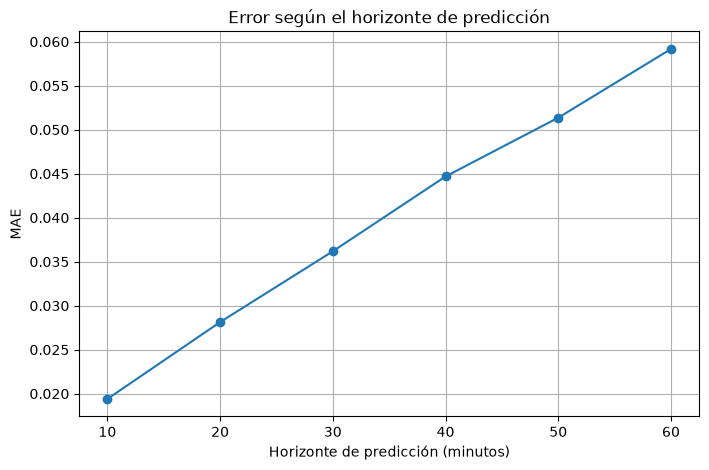

In [169]:
horizons = [
    (i + 1) * 10
    for i in range(FORECAST_HORIZON)
]

plt.figure(figsize=(8, 5))

plt.plot(
    horizons,
    mae_per_horizon,
    marker="o"
)

plt.xlabel("Horizonte de predicción (minutos)")
plt.ylabel("MAE")
plt.title("Error según el horizonte de predicción")

plt.grid(True)

plt.show()

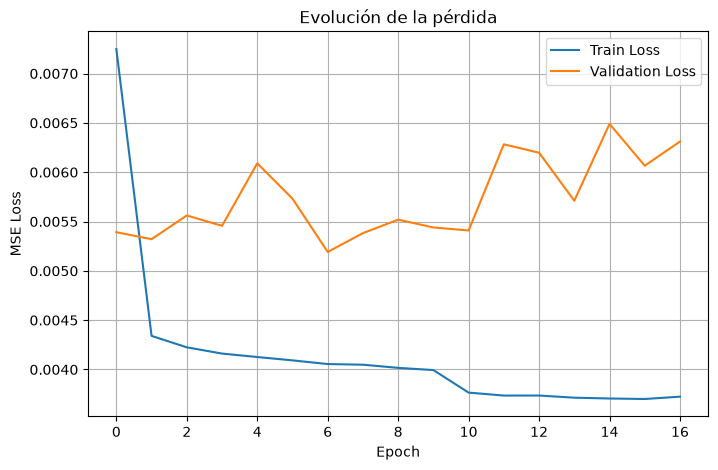

In [170]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Evolución de la pérdida")

plt.grid(True)
plt.legend()

plt.show()

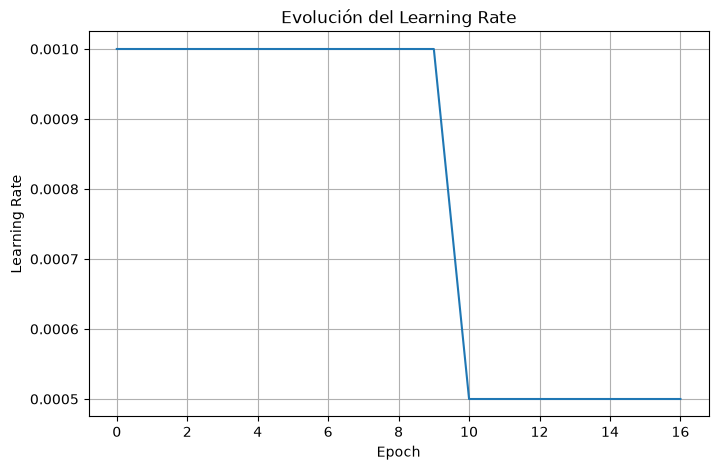

In [171]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title("Evolución del Learning Rate")

plt.grid(True)

plt.show()

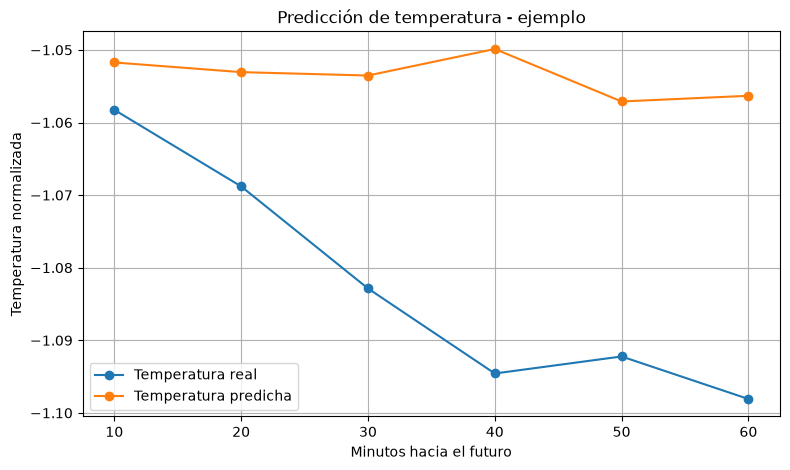

In [172]:
sample_idx = 0

real = y_true[sample_idx]
pred = y_pred[sample_idx]

horizons = [
    (i + 1) * 10
    for i in range(FORECAST_HORIZON)
]

plt.figure(figsize=(9, 5))

plt.plot(
    horizons,
    real,
    marker="o",
    label="Temperatura real"
)

plt.plot(
    horizons,
    pred,
    marker="o",
    label="Temperatura predicha"
)

plt.xlabel("Minutos hacia el futuro")
plt.ylabel("Temperatura normalizada")

plt.title(
    "Predicción de temperatura - ejemplo"
)

plt.grid(True)
plt.legend()

plt.show()

In [173]:
temperature_mean = scaler.mean_[temperature_index]
temperature_std = scaler.scale_[temperature_index]

print("Media temperatura:", temperature_mean)
print("Desviación estándar:", temperature_std)

Media temperatura: 9.184421897121284
Desviación estándar: 8.537083826212388


In [174]:
y_true_celsius = (
    y_true * temperature_std
    + temperature_mean
)

y_pred_celsius = (
    y_pred * temperature_std
    + temperature_mean
)

In [175]:
mae_celsius = mean_absolute_error(
    y_true_celsius.flatten(),
    y_pred_celsius.flatten()
)

mse_celsius = mean_squared_error(
    y_true_celsius.flatten(),
    y_pred_celsius.flatten()
)

rmse_celsius = np.sqrt(mse_celsius)

print(f"MAE  : {mae_celsius:.4f} °C")
print(f"MSE  : {mse_celsius:.4f} °C²")
print(f"RMSE : {rmse_celsius:.4f} °C")

MAE  : 0.3399 °C
MSE  : 0.2687 °C²
RMSE : 0.5183 °C


# Desnormalizar

In [176]:
# ============================================
# Desnormalizar temperatura
# ============================================

temperature_index = feature_columns.index("T (degC)")

# Media y desviación estándar utilizadas por StandardScaler
temperature_mean = scaler.mean_[temperature_index]
temperature_std = scaler.scale_[temperature_index]

print("Media de temperatura:", temperature_mean)
print("Desviación estándar:", temperature_std)


# ============================================
# Convertir y_true y y_pred nuevamente a °C
# ============================================

y_true_celsius = (
    y_true * temperature_std
    + temperature_mean
)

y_pred_celsius = (
    y_pred * temperature_std
    + temperature_mean
)


print("\nFormas:")
print("y_true:", y_true_celsius.shape)
print("y_pred:", y_pred_celsius.shape)


# ============================================
# Mostrar primer ejemplo
# ============================================

print("\nPrimer ejemplo:")
print("Temperaturas reales:")
print(y_true_celsius[0])

print("\nTemperaturas predichas:")
print(y_pred_celsius[0])

Media de temperatura: 9.184421897121284
Desviación estándar: 8.537083826212388

Formas:
y_true: (52110, 6)
y_pred: (52110, 6)

Primer ejemplo:
Temperaturas reales:
[ 0.15000044  0.06000017 -0.05999986 -0.16000005 -0.14000021 -0.1899998 ]

Temperaturas predichas:
[0.2057083  0.19434365 0.19035732 0.22155185 0.15984567 0.16653195]


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Métricas en °C

mae_celsius = mean_absolute_error(
    y_true_celsius.flatten(),
    y_pred_celsius.flatten()
)

mse_celsius = mean_squared_error(
    y_true_celsius.flatten(),
    y_pred_celsius.flatten()
)

rmse_celsius = np.sqrt(mse_celsius)


print("MÉTRICAS EN °C")

print(f"MAE : {mae_celsius:.4f} °C")
print(f"MSE : {mse_celsius:.4f} °C²")
print(f"RMSE: {rmse_celsius:.4f} °C")

MÉTRICAS EN °C
MAE : 0.3399 °C
MSE : 0.2687 °C²
RMSE: 0.5183 °C


In [ ]:
mae_per_horizon_celsius = []

print("MAE POR HORIZONTE")

for i in range(FORECAST_HORIZON):

    mae_i = mean_absolute_error(
        y_true_celsius[:, i],
        y_pred_celsius[:, i]
    )

    mae_per_horizon_celsius.append(mae_i)

    print(
        f"+{(i + 1) * 10} minutos → "
        f"MAE: {mae_i:.4f} °C"
    )

MAE POR HORIZONTE
+10 minutos → MAE: 0.1656 °C
+20 minutos → MAE: 0.2402 °C
+30 minutos → MAE: 0.3089 °C
+40 minutos → MAE: 0.3814 °C
+50 minutos → MAE: 0.4385 °C
+60 minutos → MAE: 0.5051 °C


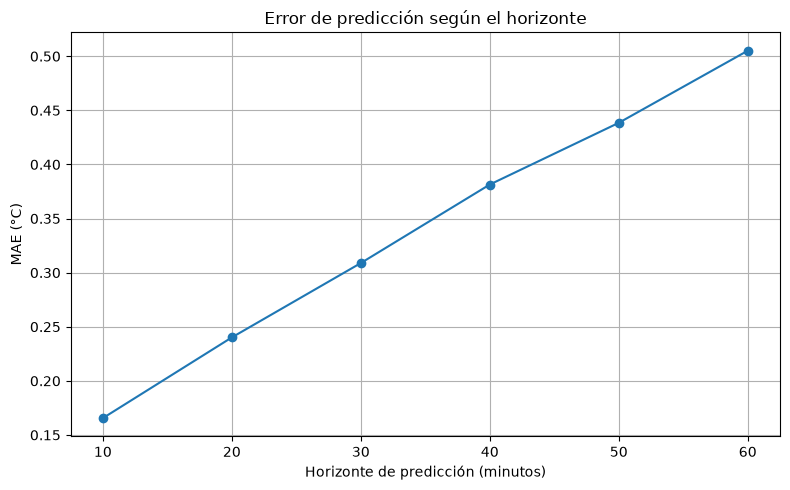

In [179]:
horizons = [
    (i + 1) * 10
    for i in range(FORECAST_HORIZON)
]

plt.figure(figsize=(8, 5))

plt.plot(
    horizons,
    mae_per_horizon_celsius,
    marker="o"
)

plt.xlabel("Horizonte de predicción (minutos)")
plt.ylabel("MAE (°C)")
plt.title("Error de predicción según el horizonte")

plt.xticks(horizons)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("PRIMERA PREDICCIÓN")

for i in range(FORECAST_HORIZON):

    minuto = (i + 1) * 10

    real = y_true_celsius[0, i]
    pred = y_pred_celsius[0, i]

    error = abs(real - pred)

    print(
        f"+{minuto:2d} min | "
        f"Real: {real:7.3f} °C | "
        f"Predicción: {pred:7.3f} °C | "
        f"Error: {error:.3f} °C"
    )

PRIMERA PREDICCIÓN
+10 min | Real:   0.150 °C | Predicción:   0.206 °C | Error: 0.056 °C
+20 min | Real:   0.060 °C | Predicción:   0.194 °C | Error: 0.134 °C
+30 min | Real:  -0.060 °C | Predicción:   0.190 °C | Error: 0.250 °C
+40 min | Real:  -0.160 °C | Predicción:   0.222 °C | Error: 0.382 °C
+50 min | Real:  -0.140 °C | Predicción:   0.160 °C | Error: 0.300 °C
+60 min | Real:  -0.190 °C | Predicción:   0.167 °C | Error: 0.357 °C


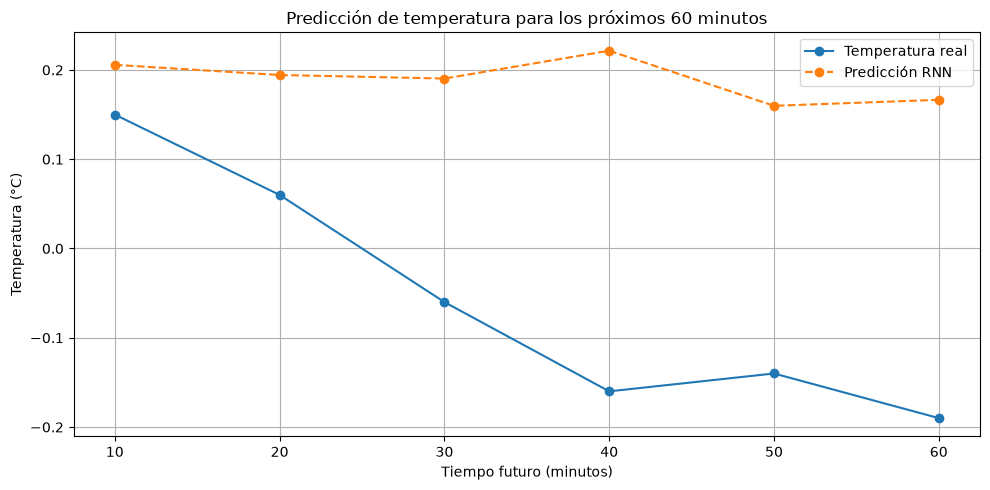

In [181]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizons,
    y_true_celsius[0],
    marker="o",
    label="Temperatura real"
)

plt.plot(
    horizons,
    y_pred_celsius[0],
    marker="o",
    linestyle="--",
    label="Predicción RNN"
)

plt.xlabel("Tiempo futuro (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Predicción de temperatura para los próximos 60 minutos")

plt.xticks(horizons)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

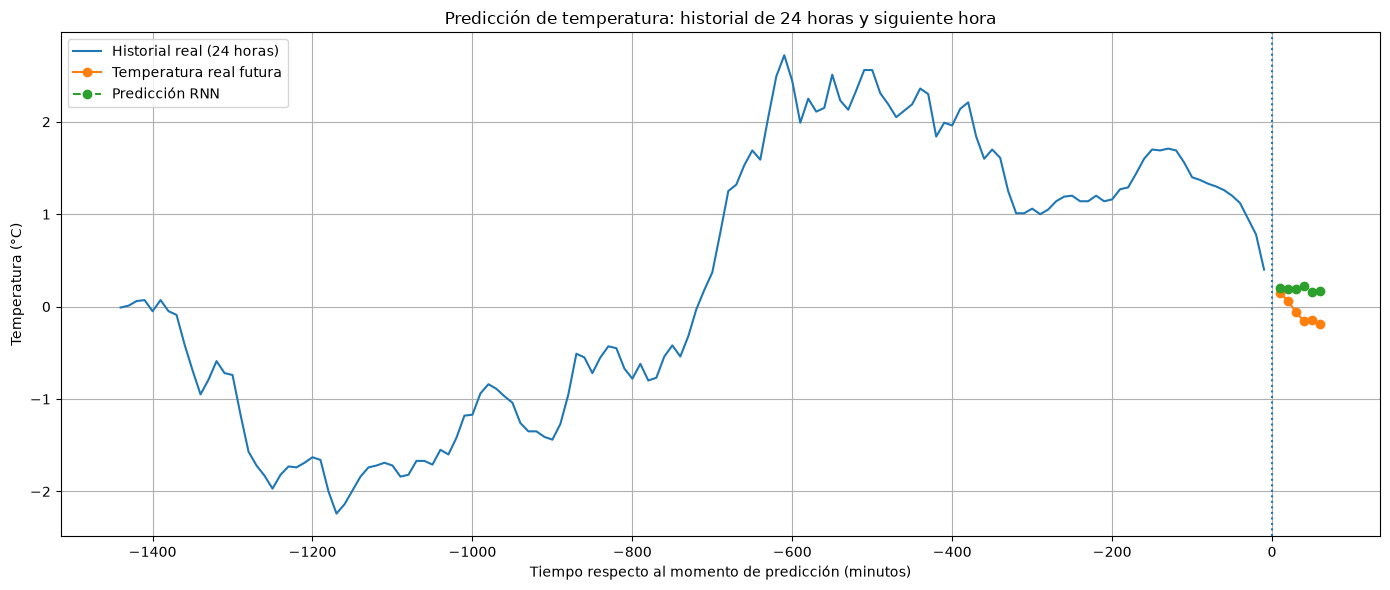

In [ ]:
# VISUALIZACIÓN:
# 24 HORAS DE HISTORIAL + 60 MINUTOS FUTUROS

# Tomamos el primer ejemplo del test
sample_index = 0

# Secuencia de entrada
X_sample_test = X_test_data[
    sample_index:
    sample_index + SEQUENCE_LENGTH
]

# Temperatura histórica normalizada
temperature_history = X_sample_test[
    :,
    temperature_index
]

# Desnormalizar historial
temperature_history_celsius = (
    temperature_history * temperature_std
    + temperature_mean
)

# Temperatura real futura
future_real = y_true_celsius[sample_index]

# Temperatura predicha
future_pred = y_pred_celsius[sample_index]

# ============================================
# Eje temporal
# ============================================

history_minutes = np.arange(
    -SEQUENCE_LENGTH * 10,
    0,
    10
)

future_minutes = np.arange(
    10,
    FORECAST_HORIZON * 10 + 1,
    10
)

# ============================================
# Gráfica
# ============================================

plt.figure(figsize=(14, 6))

# Historial
plt.plot(
    history_minutes,
    temperature_history_celsius,
    label="Historial real (24 horas)"
)

# Futuro real
plt.plot(
    future_minutes,
    future_real,
    marker="o",
    label="Temperatura real futura"
)

# Predicción
plt.plot(
    future_minutes,
    future_pred,
    marker="o",
    linestyle="--",
    label="Predicción RNN"
)

# Momento actual
plt.axvline(
    x=0,
    linestyle=":"
)

plt.xlabel("Tiempo respecto al momento de predicción (minutos)")
plt.ylabel("Temperatura (°C)")

plt.title(
    "Predicción de temperatura: historial de 24 horas y siguiente hora"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

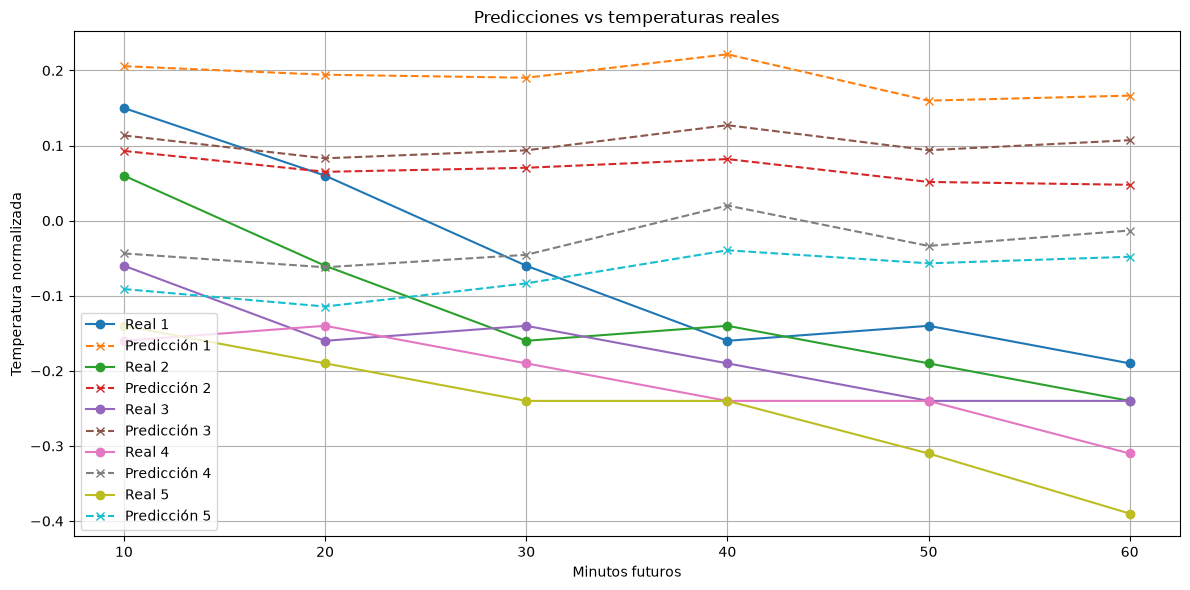

In [183]:
# ======================================
# COMPARACIÓN DE VARIAS PREDICCIONES
# ======================================

num_examples = 5

plt.figure(figsize=(12, 6))

for i in range(num_examples):

    real = y_true_celsius[i]
    pred = y_pred_celsius[i]

    horizons = np.arange(1, FORECAST_HORIZON + 1) * 10

    plt.plot(
        horizons,
        real,
        marker="o",
        label=f"Real {i+1}"
    )

    plt.plot(
        horizons,
        pred,
        marker="x",
        linestyle="--",
        label=f"Predicción {i+1}"
    )

plt.xlabel("Minutos futuros")
plt.ylabel("Temperatura normalizada")
plt.title("Predicciones vs temperaturas reales")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_test_examples(
    X_test_data,
    y_true_celsius,
    y_pred_celsius,
    temperature_index,
    temperature_mean,
    temperature_std,
    start_index=0,
    num_examples=10
):
    

    
    end_index = min(
        start_index + num_examples,
        len(y_true_celsius)
    )
    
    num_examples_real = end_index - start_index

  
    
    rows = 2
    cols = 5
    
    fig, axes = plt.subplots(
        nrows=rows,
        ncols=cols,
        figsize=(20, 8),
        sharey=True
    )

    axes = axes.flatten()

 
    
    history_steps = np.arange(
        144
    )

    future_steps = np.arange(
        144,
        150
    )


    
    for i in range(num_examples_real):

        index = start_index + i

        ax = axes[i]


        temperature_history = X_test_data[
            index:index + SEQUENCE_LENGTH,
            temperature_index
        ]

        # Desnormalizar
        temperature_history_celsius = (
            temperature_history * temperature_std
            + temperature_mean
        )

        # Temperaturas futuras reales

        real = y_true_celsius[index]

      

        pred = y_pred_celsius[index]

       

        ax.plot(
            history_steps,
            temperature_history_celsius,
            ".-",
            label="Historial"
        )

      

        ax.plot(
            future_steps,
            real,
            "bx",
            markersize=8,
            label="Real"
        )

       
        ax.plot(
            future_steps,
            pred,
            "ro",
            markersize=5,
            label="Predicción"
        )

        ax.axvline(
            x=143,
            linestyle=":"
        )

        ax.grid(True)

        ax.set_title(
            f"Ejemplo {index}"
        )

        ax.set_xlabel(
            "Mediciones (10 min)"
        )

        ax.set_ylabel(
            "Temperatura (°C)"
        )

  

    for i in range(num_examples_real, len(axes)):
        axes[i].set_visible(False)



    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        fontsize=12
    )

    fig.suptitle(
        "RNN: 24 horas de historial + 60 minutos de predicción",
        fontsize=16
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    plt.show()

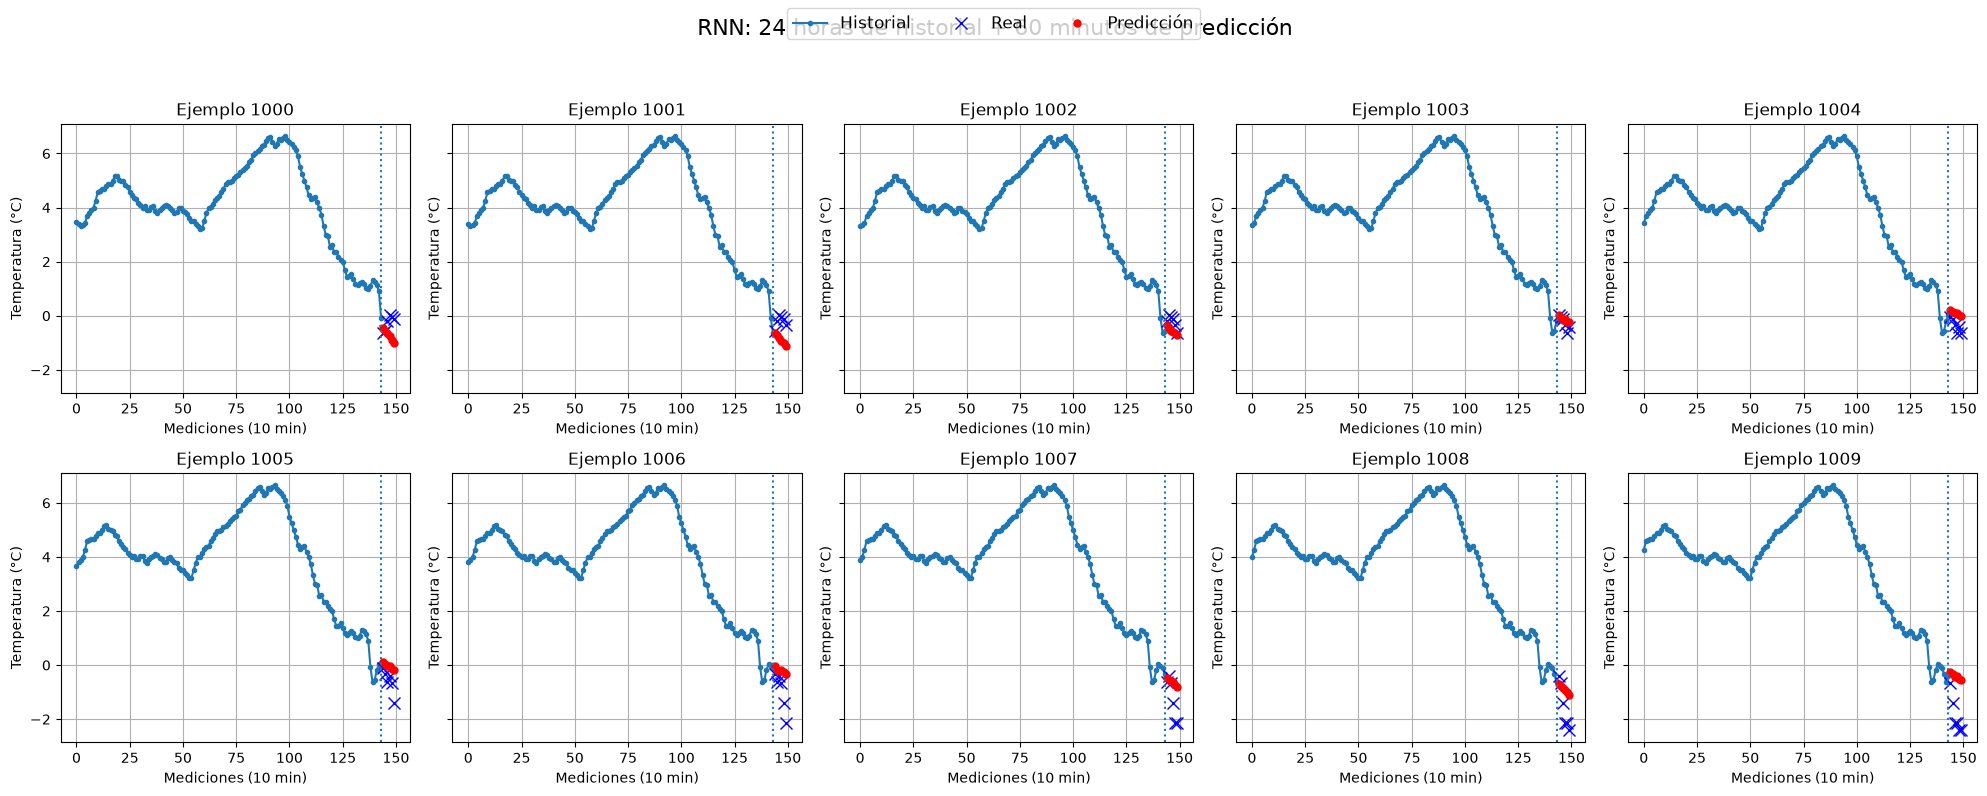

In [185]:
plot_test_examples(
    X_test_data,
    y_true_celsius,
    y_pred_celsius,
    temperature_index,
    temperature_mean,
    temperature_std,
    start_index=1000,
    num_examples=10
)

In [188]:
tolerancia = 0.5

errores = np.abs(y_true_celsius - y_pred_celsius)

porcentaje_dentro = np.mean(errores <= tolerancia) * 100

print(
    f"Predicciones dentro de ±{tolerancia} °C: "
    f"{porcentaje_dentro:.2f}%"
)

Predicciones dentro de ±0.5 °C: 78.51%


In [189]:
for tolerancia in [0.1, 0.2, 0.5, 1.0]:

    porcentaje = np.mean(
        np.abs(y_true_celsius - y_pred_celsius) <= tolerancia
    ) * 100

    print(
        f"Error ≤ ±{tolerancia} °C: "
        f"{porcentaje:.2f}%"
    )

Error ≤ ±0.1 °C: 26.41%
Error ≤ ±0.2 °C: 47.18%
Error ≤ ±0.5 °C: 78.51%
Error ≤ ±1.0 °C: 94.25%
